# Boolean circuits with an autoregressive Transformer
## Generate a symbolic reasoning trace, then the answer

This tutorial implements the Transformer design supplied with this notebook:
a **single causal self-attention layer, four heads, residual connections, one
hidden ReLU MLP, and no LayerNorm**. The learned parameters are token and position
embeddings, attention projections, MLP weights, and a vocabulary readout.

The model generates a visible **symbolic reasoning trace**: a gate and a four-bit
state at each step. This is task-specific chain-of-thought supervision, not a
natural-language explanation. At inference, each new token comes from the model's
logits and is appended to its input; gold intermediate states are never supplied.

We compare:

1. A **fixed hand-coded causal Transformer** that constructs the correct trace.
2. An **outcome-trained Transformer** that learns a short answer continuation.
3. A **process-trained Transformer** that learns a gate/state trace and answer.

The two learned models use identical architecture, initial parameters, circuit
examples, minibatch indices, and update count. Process examples have longer
continuations and more target tokens, so this is not a compute-matched experiment.
The hand-coded reference uses a larger, structured representation and MLP; it is
not a proof that the narrower learned model can express the same construction.

Run top to bottom in the project's Python environment. PyTorch, NumPy, pandas,
Matplotlib, and IPython are required. CPU works; the full training and animation
can take several minutes. Reduce `STEPS` for a smoke run, without expecting the
same accuracy. The functions are grouped into task, tokenization, model,
training, evaluation, and visualization cells.

In [18]:
import copy
import math
import random
from dataclasses import dataclass
from itertools import permutations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from IPython.display import HTML, display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BITS = 4
N_STATES = 2 ** N_BITS
DEPTH = 4
TRAIN_SIZE = 8_000
TEST_SIZE = 300
STEPS = 5_000
BATCH_SIZE = 128
LR = 2e-3
D_MODEL = 96
N_HEADS = 4
D_FF = 192
DATA_SEED, TEST_SEED, MODEL_SEED, BATCH_SEED = 123, 9000, 42, 2026
SNAPSHOT_STRIDE = max(1, (STEPS + 19) // 20)  # About 21 rendered frames.
SNAPSHOT_STEPS = sorted(set(range(0, STEPS + 1, SNAPSHOT_STRIDE)) | {STEPS})
CHECKPOINTS = sorted({step for step in [0, 100, 250, 500, STEPS] if step <= STEPS})
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False})
print(f"Device: {DEVICE}; training updates per model: {STEPS}")

Device: cuda; training updates per model: 5000


## 1. Exact circuits provide the training labels

Index 0 is the **leftmost** bit. The generator chooses a gate family uniformly,
then distinct indices within that family. There are 52 gate strings; symmetric
spellings such as `s01` and `s10` are retained as separate tokens.

| Gate | Operation | Example |
|---|---|---|
| `x0` | Flip bit 0 | `0000 → 1000` |
| `c01` | Flip bit 1 when bit 0 is 1 | `1000 → 1100` |
| `s01` | Swap bits 0 and 1 | `1000 → 0100` |
| `t012` | Flip bit 2 when bits 0 and 1 are both 1 | `1100 → 1110` |

These Python functions create labels and initialize the fixed reference weights.
The learned Transformer's forward pass and generation loop never call them.

In [19]:
def bits(value):
    """Decode an integer; index 0 is the leftmost bit."""
    return [int(bit) for bit in f"{value:0{N_BITS}b}"]


def state_text(state):
    """Format a list of bits as a readable state such as '1000'."""
    return "".join(map(str, state))


def make_gate_names(n_bits):
    """List each legal gate string in a stable order."""
    gates = [f"x{i}" for i in range(n_bits)]
    for operation in ("c", "s"):
        gates.extend(f"{operation}{i}{j}" for i, j in permutations(range(n_bits), 2))
    gates.extend(f"t{i}{j}{k}" for i, j, k in permutations(range(n_bits), 3))
    return gates


def sample_gate(rng):
    """Choose a family uniformly, then choose its distinct bit indices."""
    operation = rng.choice("xcst")
    arity = {"x": 1, "c": 2, "s": 2, "t": 3}[operation]
    indices = rng.sample(range(N_BITS), arity)
    return operation + "".join(map(str, indices))


def apply_gate(state, gate):
    """Apply one reversible gate without modifying the input state."""
    next_state = state.copy()
    operation = gate[0]
    indices = list(map(int, gate[1:]))
    if operation == "x":
        target, = indices
        next_state[target] ^= 1
    elif operation == "c":
        control, target = indices
        next_state[target] ^= next_state[control]
    elif operation == "s":
        left, right = indices
        next_state[left], next_state[right] = next_state[right], next_state[left]
    elif operation == "t":
        control_a, control_b, target = indices
        next_state[target] ^= next_state[control_a] & next_state[control_b]
    else:
        raise ValueError(f"Unknown gate: {gate}")
    return next_state


def phi(state_int, gate):
    """Integer version of the exact Boolean transition rule."""
    return int(state_text(apply_gate(bits(state_int), gate)), 2)


def sample_example(rng, depth):
    """Return the start, gate names, and gold state after every gate."""
    start = rng.randrange(N_STATES)
    gates = [sample_gate(rng) for _ in range(depth)]
    states = []
    current = start
    for gate in gates:
        current = phi(current, gate)
        states.append(current)
    return start, gates, states


GATES = make_gate_names(N_BITS)
gate_to_id = {gate: index for index, gate in enumerate(GATES)}
assert len(GATES) == 52

@dataclass
class Circuit:
    start: int
    gates: list[str]
    states: list[int]

    @property
    def answer(self):
        return self.states[-1]


def make_circuits(size, seed, depth):
    rng = random.Random(seed)
    return [Circuit(*sample_example(rng, depth)) for _ in range(size)]


train_circuits = make_circuits(TRAIN_SIZE, DATA_SEED, DEPTH)
test_circuits = make_circuits(TEST_SIZE, TEST_SEED, DEPTH)
example = test_circuits[0]
print("Start:", state_text(bits(example.start)))
print("Gates:", example.gates)
print("Gold states:", [state_text(bits(state)) for state in example.states])

Start: 1011
Gates: ['s02', 'c31', 'c31', 't302']
Gold states: ['1011', '1111', '1011', '1001']


## 2. The same prompt, two continuations

Each four-bit state is one semantic token such as `S1000`. These are not separate
bit tokens. Gate strings are also single tokens, giving a vocabulary of 72 tokens.

```text
Prompt for both:   S0000 x0 c01 t012 s03 <SEP>
Outcome target:                             <COLON> S0111 <EOS>
Process target:                             x0 S1000 c01 S1100 t012 S1110 s03 S0111 <COLON> S0111 <EOS>
```

There is no mode token. Separate models learn their own output format. Outcome
supervision includes the delimiter and EOS tokens as well as the final state;
process supervision includes gates, all intermediate states, and the final answer.

In [20]:
class CircuitTokenizer:
    """Map semantic states, gates, and separators to vocabulary indices."""
    def __init__(self, gates, n_states):
        self.n_states = n_states
        self.gates = list(gates)
        self.tokens = [f"S{state:04b}" for state in range(n_states)] + self.gates
        self.tokens += ["<SEP>", "<COLON>", "<EOS>", "<PAD>"]
        self.ids = {token: index for index, token in enumerate(self.tokens)}
        self.sep, self.colon, self.eos, self.pad = [
            self.ids[token] for token in ("<SEP>", "<COLON>", "<EOS>", "<PAD>")]

    def prompt(self, circuit):
        return [circuit.start] + [self.ids[gate] for gate in circuit.gates] + [self.sep]

    def continuation(self, circuit, mode):
        ending = [self.colon, circuit.answer, self.eos]
        if mode == "outcome":
            return ending
        if mode == "process":
            trace = []
            for gate, state in zip(circuit.gates, circuit.states):
                trace.extend([self.ids[gate], state])
            return trace + ending
        raise ValueError(f"Unknown supervision mode: {mode}")

    def decode(self, ids):
        return " ".join(self.tokens[int(index)] for index in ids)


tokenizer = CircuitTokenizer(GATES, N_STATES)
for label, ids in [("Prompt", tokenizer.prompt(example)),
                   ("Outcome", tokenizer.continuation(example, "outcome")),
                   ("Process", tokenizer.continuation(example, "process"))]:
    print(f"{label:8s}: {tokenizer.decode(ids)}")

Prompt  : S1011 s02 c31 c31 t302 <SEP>
Outcome : <COLON> S1001 <EOS>
Process : s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>


## 3. A trainable causal Transformer

```text
Token IDs + positions
          ↓
     embeddings h₀
          ↓
  causal multi-head attention ──→ add h₀
          ↓
       ReLU MLP ────────────────→ add residual
          ↓
   logits over all 72 tokens
          ↓
  choose next token → append → run again
```

At each position the model can attend to that position and earlier positions.
For a next-state prediction after a gate token, a head can retrieve a preceding
state and the MLP can combine it with the gate. Nothing explicitly tells the
learned attention where to look. It must learn from next-token losses.

| Tensor | Shape |
|---|---|
| Token IDs | `[batch, length]` |
| Hidden activations | `[batch, length, d_model]` |
| Attention per head | `[batch, heads, query_position, key_position]` |
| Vocabulary logits | `[batch, length, vocabulary]` |

No transition-matrix parameters, Python gate executor, or oracle correction are
used inside this learned model.

In [21]:
class LearnedOneLayerTransformer(nn.Module):
    """One causal attention layer and one hidden ReLU MLP, with residuals."""
    def __init__(self, vocab_size, max_length, d_model, n_heads, d_ff):
        super().__init__()
        if d_model % n_heads:
            raise ValueError("d_model must be divisible by n_heads")
        self.max_length = max_length
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.attention = nn.MultiheadAttention(d_model, n_heads, dropout=0.0, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.readout = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, ids, return_attention=False):
        length = ids.shape[1]
        if length > self.max_length:
            raise ValueError(f"Input length {length} exceeds {self.max_length}")
        positions = torch.arange(length, device=ids.device)
        hidden = self.token_embedding(ids) + self.position_embedding(positions)[None]
        # True entries are forbidden: no token can see a future token.
        causal_mask = torch.ones(length, length, device=ids.device, dtype=torch.bool).triu(1)
        attended, weights = self.attention(
            hidden, hidden, hidden, attn_mask=causal_mask,
            need_weights=return_attention, average_attn_weights=False,
        )
        hidden = hidden + attended
        hidden = hidden + self.mlp(hidden)
        logits = self.readout(hidden)
        return (logits, weights) if return_attention else logits


torch.manual_seed(MODEL_SEED)
base = LearnedOneLayerTransformer(
    len(tokenizer.tokens), max_length=3 * DEPTH + 5,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
).to(DEVICE)
print(f"Trainable parameters per learned model: {sum(p.numel() for p in base.parameters()):,}")

Trainable parameters per learned model: 89,856


## 4. Construct a fixed Transformer reference

This reference uses **fixed semantic embeddings**, four dot-product causal
attention heads (three active), a ReLU MLP, and a fixed vocabulary readout.
It generates through exactly the same generic autoregressive loop as the learned
models. The Boolean rule is encoded in weights during initialization, not called
by the forward pass.

- The state head retrieves the previous state at each generated gate position.
- The gate head copies the next gate from the prompt.
- The final head copies the last computed state after `<COLON>`.
- One hidden ReLU unit per `(state, gate)` pair computes
  $\operatorname{ReLU}(\mathbf1_s+\mathbf1_g-1.5)$ and writes the target state.

Routing relies on the fixed-depth output format and absolute positions. Large,
finite attention scores approximate one-hot routing; **greedy token correctness**
is tested below, not exact one-hot probabilities or arbitrary-depth generalization.
The reference has 832 MLP units versus 192 in the default learned model.

In [22]:
class FixedAttentionHead(nn.Module):
    """Ordinary causal dot-product attention with fixed projection buffers."""
    def __init__(self, width, n_positions):
        super().__init__()
        self.register_buffer("query", torch.zeros(n_positions, width))
        self.register_buffer("key", torch.zeros(n_positions, width))
        self.register_buffer("value", torch.zeros(width, width))

    def forward(self, hidden):
        query = hidden @ self.query.T
        key = hidden @ self.key.T
        value = hidden @ self.value.T
        scores = query @ key.transpose(-2, -1) / math.sqrt(self.query.shape[0])
        length = hidden.shape[1]
        mask = torch.ones(length, length, dtype=torch.bool, device=hidden.device).triu(1)
        return scores.masked_fill(mask, -torch.inf).softmax(dim=-1) @ value


class HandcodedProcessTransformer(nn.Module):
    """Constructive fixed-depth attention/MLP solution, encoded entirely in weights."""
    def __init__(self, tokenizer, depth):
        super().__init__()
        states, gates = tokenizer.n_states, len(tokenizer.gates)
        positions = 3 * depth + 4  # Longest prefix before the EOS prediction.
        # Disjoint feature blocks keep the construction readable.
        state = slice(0, states)
        gate = slice(state.stop, state.stop + gates)
        position = slice(gate.stop, gate.stop + positions)
        retrieved_state = slice(position.stop, position.stop + states)
        output_gate = slice(retrieved_state.stop, retrieved_state.stop + gates)
        output_state = slice(output_gate.stop, output_gate.stop + states)
        width = output_state.stop
        self.max_length = positions
        self.heads = nn.ModuleList([FixedAttentionHead(width, positions) for _ in range(4)])
        self.register_buffer("token_features", torch.zeros(len(tokenizer.tokens), width))
        self.register_buffer("position_features", torch.zeros(positions, width))
        self.register_buffer("mlp_in", torch.zeros(states * gates, width))
        self.register_buffer("mlp_bias", torch.full((states * gates,), -1.5))
        self.register_buffer("mlp_out", torch.zeros(width, states * gates))
        self.register_buffer("readout", torch.zeros(len(tokenizer.tokens), width))

        self.token_features[:states, state] = torch.eye(states)
        self.token_features[states:states + gates, gate] = torch.eye(gates)
        self.position_features[:, position] = torch.eye(positions)
        for head in self.heads:
            head.key[:, position] = torch.eye(positions)

        state_head, gate_head, final_head, _ = self.heads
        separator_position = depth + 1
        # Unused routes point to SEP, whose state and gate features are zero.
        state_routes, gate_routes = {}, {}
        for step in range(depth):
            gate_position = depth + 2 + 2 * step
            state_routes[gate_position] = 0 if step == 0 else gate_position - 1
            gate_routes[gate_position - 1] = step + 1
        final_routes = {3 * depth + 2: 3 * depth + 1}
        for head, routes in zip(self.heads[:3], [state_routes, gate_routes, final_routes]):
            for destination in range(separator_position, positions):
                origin = routes.get(destination, separator_position)
                head.query[origin, position.start + destination] = 80.0
        state_head.value[retrieved_state, state] = torch.eye(states)
        gate_head.value[output_gate, gate] = torch.eye(gates)
        final_head.value[output_state, state] = torch.eye(states)

        # Each hidden unit recognizes one pair. This is initialization only.
        for state_id in range(states):
            for gate_id, gate_name in enumerate(tokenizer.gates):
                unit = state_id * gates + gate_id
                self.mlp_in[unit, retrieved_state.start + state_id] = 1
                self.mlp_in[unit, gate.start + gate_id] = 1
                target = phi(state_id, gate_name)
                self.mlp_out[output_state.start + target, unit] = 2
        self.readout[:states, output_state] = 20 * torch.eye(states)
        self.readout[states:states + gates, output_gate] = 20 * torch.eye(gates)
        self.readout[tokenizer.colon, position.start + 3 * depth + 1] = 20
        self.readout[tokenizer.eos, position.start + 3 * depth + 3] = 20

    def forward(self, ids):
        length = ids.shape[1]
        if length > self.max_length:
            raise ValueError("Prefix exceeds the hand-coded routing layout")
        features = self.token_features[ids] + self.position_features[:length][None]
        hidden = features + sum(head(features) for head in self.heads)
        hidden = hidden + F.relu(hidden @ self.mlp_in.T + self.mlp_bias) @ self.mlp_out.T
        return hidden @ self.readout.T


handcoded_model = HandcodedProcessTransformer(tokenizer, DEPTH).to(DEVICE)

## 5. Generation feeds back predictions—not labels

The same loop serves all three models. It chooses the largest **full-vocabulary**
logit; there is no forced gate copying, state-only restriction, or oracle lookup.
EOS stops each sequence. A maximum token budget bounds malformed continuations.

In [23]:
@torch.no_grad()
def generate(model, prompts, max_new_tokens, eos_id):
    """Greedy autoregression; only previously generated tokens are fed back."""
    was_training = model.training
    model.eval()
    ids = prompts.clone()
    finished = torch.zeros(len(ids), dtype=torch.bool, device=ids.device)
    try:
        for _ in range(max_new_tokens):
            next_ids = model(ids)[:, -1].argmax(dim=-1)
            next_ids = torch.where(finished, eos_id, next_ids)
            ids = torch.cat([ids, next_ids[:, None]], dim=1)
            finished |= next_ids == eos_id
            if finished.all():
                break
        return ids
    finally:
        model.train(was_training)


def strip_after_eos(ids, eos_id):
    result = list(map(int, ids))
    return result[:result.index(eos_id) + 1] if eos_id in result else result


example_prompt = torch.tensor([tokenizer.prompt(example)], device=DEVICE)
reference_output = generate(handcoded_model, example_prompt, 2 * DEPTH + 3, tokenizer.eos)
reference_target = tokenizer.prompt(example) + tokenizer.continuation(example, "process")
assert reference_output[0].tolist() == reference_target
print("Fixed Transformer:", tokenizer.decode(reference_output[0]))

Fixed Transformer: S1011 s02 c31 c31 t302 <SEP> s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>


## 6. Shifted language-model targets and prompt masking

For a sequence `prompt + continuation`, the input is `full[:-1]` and the target
is `full[1:]`. Target positions predicting prompt tokens are marked `-100` and
ignored by cross-entropy. The position containing `<SEP>` predicts the first
continuation token and **must remain supervised**.

Teacher forcing supplies earlier gold continuation tokens during training.
Free generation in section 5 supplies the model's own tokens instead. Loss is
averaged over supervised continuation tokens, not prompt tokens.

In [24]:
@dataclass
class LanguageBatch:
    inputs: torch.Tensor
    targets: torch.Tensor

    def select(self, indices):
        return LanguageBatch(self.inputs[indices], self.targets[indices])

    def to(self, device):
        return LanguageBatch(self.inputs.to(device), self.targets.to(device))


def encode_dataset(circuits, tokenizer, mode):
    inputs, targets = [], []
    for circuit in circuits:
        prompt = tokenizer.prompt(circuit)
        full = prompt + tokenizer.continuation(circuit, mode)
        inputs.append(full[:-1])
        target = full[1:]
        target[:len(prompt) - 1] = [-100] * (len(prompt) - 1)
        targets.append(target)
    return LanguageBatch(torch.tensor(inputs), torch.tensor(targets))


def language_model_loss(model, batch):
    logits = model(batch.inputs)
    return F.cross_entropy(logits.flatten(0, 1), batch.targets.flatten(), ignore_index=-100)


def make_batch_schedule(size, steps, batch_size, seed):
    rng = random.Random(seed)
    return [[rng.randrange(size) for _ in range(batch_size)] for _ in range(steps)]


training_data = {mode: encode_dataset(train_circuits, tokenizer, mode).to(DEVICE)
                 for mode in ("outcome", "process")}
batch_schedule = make_batch_schedule(TRAIN_SIZE, STEPS, BATCH_SIZE, BATCH_SEED)
for mode, batch in training_data.items():
    print(mode, tuple(batch.inputs.shape), "supervised tokens per circuit:",
          int((batch.targets[0] != -100).sum()))

outcome (8000, 8) supervised tokens per circuit: 3
process (8000, 16) supervised tokens per circuit: 11


## 7. Probe all 832 local transitions through the Transformer

For each state and gate, run the prefix

```text
S g filler1 filler2 filler3 <SEP> g → predict the next token
```

The resulting heatmap is $M_g[s,s']=p_\theta(S_{s'}\mid\text{this prefix})$.
These are **context-dependent Transformer outputs, not learned transition
parameters**. We extract the 16 state-token probabilities from the full 72-token
softmax without renormalizing: a row may sum to less than 1 if the model predicts
non-state tokens. Local accuracy also uses full-vocabulary argmax.

This first-step process probe is an **out-of-training-format diagnostic for the
outcome model**. Poor scores can reflect this format mismatch. Fixed fillers and
one position do not establish a context-independent algorithm; teacher-forced
probes at all steps and free rollouts provide complementary checks.

In [25]:
@dataclass
class OperatorProbe:
    inputs: torch.Tensor
    targets: torch.Tensor
    oracle: torch.Tensor


def make_operator_probe(tokenizer, depth, device):
    prefixes, targets = [], []
    oracle = torch.zeros(len(tokenizer.gates), tokenizer.n_states, tokenizer.n_states)
    # Gate-major ordering lets us reshape predictions to [gate, state, next state].
    for gate_index, gate in enumerate(tokenizer.gates):
        for state in range(tokenizer.n_states):
            fillers = [f"x{index % N_BITS}" for index in range(depth - 1)]
            circuit = Circuit(state, [gate] + fillers, [])
            prefixes.append(tokenizer.prompt(circuit) + [tokenizer.ids[gate]])
            target = phi(state, gate)
            targets.append(target)
            oracle[gate_index, state, target] = 1
    return OperatorProbe(torch.tensor(prefixes, device=device),
                         torch.tensor(targets, device=device), oracle.to(device))


@torch.no_grad()
def probe_operator(model, probe):
    logits = model(probe.inputs)[:, -1]
    n_gates, n_states, _ = probe.oracle.shape
    matrices = logits.softmax(dim=-1)[:, :n_states].reshape(n_gates, n_states, n_states)
    metrics = {
        "local_accuracy": (logits.argmax(dim=-1) == probe.targets).float().mean().item(),
        "oracle_probability": (matrices * probe.oracle).sum(dim=-1).mean().item(),
        "frobenius_distance": (matrices - probe.oracle).square().sum(dim=(-1, -2)).mean().item(),
        "state_token_mass": matrices.sum(dim=-1).mean().item(),
    }
    return metrics, matrices.detach().cpu()


def make_teacher_probes(circuits, tokenizer, depth, device):
    probes = []
    for step in range(depth):
        prefixes, targets = [], []
        for circuit in circuits:
            continuation = tokenizer.continuation(circuit, "process")
            prefixes.append(tokenizer.prompt(circuit) + continuation[:2 * step + 1])
            targets.append(circuit.states[step])
        probes.append((torch.tensor(prefixes, device=device), torch.tensor(targets, device=device)))
    return probes


@torch.no_grad()
def teacher_step_accuracy(model, probes):
    correct = total = 0
    for inputs, targets in probes:
        correct += (model(inputs)[:, -1].argmax(dim=-1) == targets).sum().item()
        total += len(targets)
    return correct / total


operator_probe = make_operator_probe(tokenizer, DEPTH, DEVICE)
teacher_probes = make_teacher_probes(test_circuits, tokenizer, DEPTH, DEVICE)
reference_metrics, reference_matrices = probe_operator(handcoded_model, operator_probe)
assert reference_metrics["local_accuracy"] == 1.0
assert teacher_step_accuracy(handcoded_model, teacher_probes) == 1.0
print("Fixed Transformer on all 832 pairs:", reference_metrics)

Fixed Transformer on all 832 pairs: {'local_accuracy': 1.0, 'oracle_probability': 0.9999998807907104, 'frobenius_distance': 2.2839334048140036e-13, 'state_token_mass': 0.9999998807907104}


## 8. Evaluate complete free-running outputs

**Exact continuation** checks every generated token, including gates, states,
colon, and EOS. **Final answer** parses the state after colon from the generated
text. **Trace state accuracy** scores intermediate state positions for process
outputs. A correct final answer alone does not imply a correct trace.

The outcome model is scored on its short format, the process model on its longer
format. Their exact-continuation scores have different difficulty. Every model
receives the same test prompts.

In [26]:
@dataclass
class GenerationEvaluation:
    prompts: torch.Tensor
    targets: dict
    answers: list[int]
    depth: int


def make_generation_evaluation(circuits, tokenizer, device):
    return GenerationEvaluation(
        prompts=torch.tensor([tokenizer.prompt(c) for c in circuits], device=device),
        targets={mode: [tokenizer.continuation(c, mode) for c in circuits]
                 for mode in ("outcome", "process")},
        answers=[c.answer for c in circuits], depth=len(circuits[0].gates),
    )


def generated_answer(tokens, tokenizer):
    if tokenizer.colon not in tokens:
        return None
    index = tokens.index(tokenizer.colon) + 1
    if index < len(tokens) and tokens[index] < tokenizer.n_states:
        return tokens[index]
    return None


@torch.no_grad()
def free_run_metrics(model, evaluation, tokenizer, mode):
    budget = 3 if mode == "outcome" else 2 * evaluation.depth + 3
    output = generate(model, evaluation.prompts, budget, tokenizer.eos)
    continuations = output[:, evaluation.prompts.shape[1]:].cpu().tolist()
    predictions = [strip_after_eos(row, tokenizer.eos) for row in continuations]
    targets = evaluation.targets[mode]
    count = len(targets)
    metrics = {
        "exact_continuation": sum(p == t for p, t in zip(predictions, targets)) / count,
        "final_answer": sum(generated_answer(p, tokenizer) == a
                            for p, a in zip(predictions, evaluation.answers)) / count,
    }
    if mode == "process":
        correct = sum(len(p) > 2 * step + 1 and p[2 * step + 1] == t[2 * step + 1]
                      for p, t in zip(predictions, targets) for step in range(evaluation.depth))
        metrics["trace_state_accuracy"] = correct / (count * evaluation.depth)
    return metrics


def evaluate(model, mode, operator_probe, teacher_probes, generation_eval, tokenizer):
    local_metrics, _ = probe_operator(model, operator_probe)
    return {**local_metrics, "teacher_step_accuracy": teacher_step_accuracy(model, teacher_probes),
            **free_run_metrics(model, generation_eval, tokenizer, mode)}


generation_eval = make_generation_evaluation(test_circuits, tokenizer, DEVICE)
fixed_evaluation = evaluate(handcoded_model, "process", operator_probe,
                            teacher_probes, generation_eval, tokenizer)
assert fixed_evaluation["exact_continuation"] == 1.0
print("Hand-coded Transformer, 300 free-running test circuits:", fixed_evaluation)

Hand-coded Transformer, 300 free-running test circuits: {'local_accuracy': 1.0, 'oracle_probability': 0.9999998807907104, 'frobenius_distance': 2.2839334048140036e-13, 'state_token_mass': 0.9999998807907104, 'teacher_step_accuracy': 1.0, 'exact_continuation': 1.0, 'final_answer': 1.0, 'trace_state_accuracy': 1.0}


## 9. Train and record dynamics

`train_step` performs one gradient update. `record_snapshot` evaluates a fixed
subset of 256 training examples and all operator probes after the update.
`train_one_model` owns a fresh copy and optimizer; `run_experiment` pairs the two
conditions. Rerunning the experiment starts again from `base`.

Minibatch loss is measured **before** an update; snapshot loss is measured
**after** it on a fixed training subset. The latter is used in the animation.
Checkpoint evaluation generates actual tokens without teacher forcing.

In [27]:
def train_step(model, batch, optimizer):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    loss = language_model_loss(model, batch)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def record_snapshot(model, step, training_probe, operator_probe):
    metrics, matrices = probe_operator(model, operator_probe)
    return {"step": step, "training_probe_loss": language_model_loss(model, training_probe).item(),
            **metrics, "matrices": matrices.clone()}


def train_one_model(base, mode, data, batch_schedule, learning_rate, snapshot_steps,
                    checkpoints, operator_probe, teacher_probes, generation_eval, tokenizer):
    model = copy.deepcopy(base)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0)
    fixed_training_probe = data.select(slice(0, 256))
    frames = [record_snapshot(model, 0, fixed_training_probe, operator_probe)]
    history = [{"step": 0, "mode": mode,
                **evaluate(model, mode, operator_probe, teacher_probes, generation_eval, tokenizer)}]
    losses = []
    for step, indices in enumerate(batch_schedule, 1):
        loss = train_step(model, data.select(indices), optimizer)
        losses.append({"step": step, "mode": mode, "loss": loss})
        if step in snapshot_steps:
            frames.append(record_snapshot(model, step, fixed_training_probe, operator_probe))
        if step in checkpoints:
            metrics = evaluate(model, mode, operator_probe, teacher_probes, generation_eval, tokenizer)
            history.append({"step": step, "mode": mode, **metrics})
            print(f"{mode:7s} step {step:4d}: loss={loss:.3f}, "
                  f"local={metrics['local_accuracy']:.3f}, "
                  f"exact generation={metrics['exact_continuation']:.3f}", flush=True)
    return model, pd.DataFrame(history), pd.DataFrame(losses), frames


def run_experiment(base, training_data, batch_schedule, learning_rate, snapshot_steps,
                   checkpoints, operator_probe, teacher_probes, generation_eval, tokenizer):
    models, histories, loss_tables, snapshots = {}, [], [], {}
    for mode in ("outcome", "process"):
        model, history, losses, frames = train_one_model(
            base, mode, training_data[mode], batch_schedule, learning_rate, snapshot_steps,
            checkpoints, operator_probe, teacher_probes, generation_eval, tokenizer)
        models[mode], snapshots[mode] = model, frames
        histories.append(history)
        loss_tables.append(losses)
    return models, pd.concat(histories, ignore_index=True), pd.concat(loss_tables, ignore_index=True), snapshots

In [28]:
models, history, batch_losses, training_snapshots = run_experiment(
    base, training_data, batch_schedule, LR, SNAPSHOT_STEPS, CHECKPOINTS,
    operator_probe, teacher_probes, generation_eval, tokenizer,
)
display(history)

outcome step  100: loss=0.929, local=0.062, exact generation=0.083
outcome step  250: loss=0.890, local=0.049, exact generation=0.093
outcome step  500: loss=0.871, local=0.047, exact generation=0.080


outcome step 5000: loss=0.531, local=0.070, exact generation=0.240
process step  100: loss=0.486, local=0.619, exact generation=0.117
process step  250: loss=0.006, local=0.992, exact generation=0.993
process step  500: loss=0.001, local=1.000, exact generation=1.000
process step 5000: loss=0.000, local=1.000, exact generation=1.000


,step,mode,local_accuracy,oracle_probability,frobenius_distance,state_token_mass,teacher_step_accuracy,exact_continuation,final_answer,trace_state_accuracy
0,0,outcome,0.004808,0.013672,1.563880e+01,0.218152,0.012500,0.000000,0.000000,NaN
1,100,outcome,0.062500,0.055852,1.528255e+01,0.662132,0.021667,0.083333,0.083333,NaN
2,250,outcome,0.049279,0.054821,1.523998e+01,0.712456,0.017500,0.093333,0.093333,NaN
3,500,outcome,0.046875,0.052229,1.520446e+01,0.709238,0.016667,0.080000,0.080000,NaN
4,5000,outcome,0.069712,0.057964,2.068483e+01,0.900757,0.037500,0.240000,0.240000,NaN
5,0,process,0.004808,0.013672,1.563880e+01,0.218152,0.012500,0.000000,0.000000,0.001667
6,100,process,0.618990,0.485789,8.419534e+00,0.998276,0.560833,0.116667,0.166667,0.340000
7,250,process,0.991587,0.968207,2.382143e-01,0.999981,0.998333,0.993333,0.993333,0.995000
8,500,process,1.000000,0.998094,4.397199e-04,0.999996,1.000000,1.000000,1.000000,1.000000
9,5000,process,1.000000,0.999995,4.776429e-09,1.000000,1.000000,1.000000,1.000000,1.000000


## 10. Animate loss and the Transformer response for every gate

All **52 gates** appear in each grid. Left is the fixed Transformer's response;
center and right are the learned models' responses. Above them, loss, all-pairs
local accuracy, oracle probability, and state-table distance advance together.
Rows within tiles are current states; columns are next-state tokens. The color
scale stays 0–1. Dark rows can mean probability went to non-state tokens.

These are responses to the first-step process probe, **not raw attention weights
or context-independent transition parameters**. The next section shows actual
attention heads. A low outcome-model probe score is not by itself evidence that
its internal Boolean computation is absent.

The animation replays saved checkpoints with Play/Pause and a slider. Use the
HTML export for a full-size browser view. Pass `gates=["x0", "c01"]` for a close-up.

In [29]:
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


def make_gate_mosaic(matrices, gate_indices, columns=4):
    """Arrange [gate, state, state] matrices into one image with blank gutters."""
    tables = matrices.detach().cpu().numpy()
    size = tables.shape[-1]
    rows = (len(gate_indices) + columns - 1) // columns
    # Extra space above each tile holds its gate name. NaN is drawn as white.
    tile_height, tile_width = size + 6, size + 3
    mosaic = np.full((rows * tile_height, columns * tile_width), np.nan)
    for position, gate_index in enumerate(gate_indices):
        row, column = divmod(position, columns)
        top = row * tile_height + 5
        left = column * tile_width
        mosaic[top:top + size, left:left + size] = tables[gate_index]
    return mosaic


def draw_gate_grid(ax, matrices, gate_ids, gates, title, columns):
    """Create one mosaic image and its fixed, readable gate labels."""
    size = matrices.shape[-1]
    gate_indices = [gate_ids[gate] for gate in gates]
    palette = plt.get_cmap("viridis").copy()
    palette.set_bad("white")
    image = ax.imshow(
        make_gate_mosaic(matrices, gate_indices, columns),
        vmin=0, vmax=1, cmap=palette, interpolation="nearest", aspect="equal",
    )
    for position, gate in enumerate(gates):
        row, column = divmod(position, columns)
        ax.text(column * (size + 3) + (size - 1) / 2,
                row * (size + 6) + 2, gate, ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_axis_off()
    return image


def draw_metric_curves(axes, snapshots):
    """Prepare fixed axes and empty lines; return lines indexed by metric/mode."""
    colors = {"outcome": "#d97706", "process": "#0284c7"}
    specifications = [
        ("training_probe_loss", "Training loss (fixed examples)", "Negative log likelihood"),
        ("local_accuracy", "Local process-prefix probe", "Accuracy / probability"),
        ("frobenius_distance", "State-table distance to oracle", "Mean squared Frobenius distance"),
    ]
    last_step = snapshots["outcome"][-1]["step"]
    lines = {}
    for ax, (metric, title, ylabel) in zip(axes, specifications):
        ax.set(title=title, xlabel="Optimization step", ylabel=ylabel,
               xlim=(0, max(1, last_step)))
        ax.grid(alpha=0.2)
        for mode, color in colors.items():
            lines[metric, mode], = ax.plot([], [], color=color, label=mode)
        if metric == "local_accuracy":
            for mode, color in colors.items():
                lines["oracle_probability", mode], = ax.plot(
                    [], [], "--", color=color, label=f"{mode} probability")
            ax.set_ylim(-0.03, 1.05)
        else:
            maximum = max(row[metric] for mode in colors for row in snapshots[mode])
            ax.set_ylim(0, max(0.1, maximum * 1.12))
        ax.legend(fontsize=8, loc="best")
    return lines


def validate_animation_inputs(snapshots, oracle, gate_ids, gates, interval_ms, columns):
    """Catch input mistakes before spending time rendering animation frames."""
    if interval_ms <= 0 or not isinstance(columns, int) or columns < 1:
        raise ValueError("interval_ms must be positive and columns a positive integer.")
    if not gates or any(gate not in gate_ids for gate in gates):
        raise ValueError("Provide at least one known gate name.")
    if any(not snapshots.get(mode) for mode in ("outcome", "process")):
        raise ValueError("Provide nonempty outcome and process snapshots.")
    steps = [frame["step"] for frame in snapshots["outcome"]]
    if steps != [frame["step"] for frame in snapshots["process"]]:
        raise ValueError("Both conditions must use the same snapshot steps.")
    if any(right <= left for left, right in zip(steps, steps[1:])):
        raise ValueError("Snapshot steps must be strictly increasing.")
    if oracle.ndim != 3 or oracle.shape[-2] != oracle.shape[-1]:
        raise ValueError("Oracle must have shape [gates, states, states].")
    if any(not 0 <= gate_ids[gate] < len(oracle) for gate in gates):
        raise ValueError("Gate indices must refer to valid oracle matrices.")
    for mode in ("outcome", "process"):
        for frame in snapshots[mode]:
            if frame["matrices"].shape != oracle.shape:
                raise ValueError("Snapshot matrices must have the oracle's shape.")
    return steps


def render_animation(animation, save_path=None):
    """Embed frames in an HTML player, optionally also writing a browser copy."""
    with plt.rc_context({"animation.embed_limit": 120}):
        html = animation.to_jshtml(default_mode="once")
    if save_path is not None:
        Path(save_path).write_text(
            "<!doctype html><html><head><meta charset='utf-8'>"
            "<title>All-gate training dynamics</title></head><body>"
            + html + "</body></html>", encoding="utf-8",
        )
    return HTML(html)

In [30]:
def animate_training_dynamics(snapshots, oracle, gate_ids, *, gates=None,
                              interval_ms=180, columns=4, save_path=None):
    """Animate training loss and context-dependent Transformer probe responses.

    snapshots: outcome/process lists returned by run_experiment. Each frame
        contains step, training_probe_loss, local_accuracy, oracle_probability,
        frobenius_distance, and a [gate, state, state] matrix tensor.
    oracle, gate_ids: fixed Transformer probe responses and gate-name indices.
    gates: names to display; None shows ALL gates, ordered by their indices.
    interval_ms: playback delay. columns: tiles per row in each matrix grid.
    save_path: optional standalone HTML destination.

    Curves summarize all gates, even when a subset is selected for close-up.
    This function reads recorded snapshots and never modifies or trains models.
    """
    gates = sorted(gate_ids, key=gate_ids.get) if gates is None else list(gates)
    steps = validate_animation_inputs(snapshots, oracle, gate_ids, gates, interval_ms, columns)
    columns = min(columns, len(gates))
    gate_indices = [gate_ids[gate] for gate in gates]
    rows = (len(gates) + columns - 1) // columns

    # Three large mosaics are faster to update than 156 individual heatmap axes.
    grid_height = max(3, rows * 1.25)
    fig = plt.figure(figsize=(17, grid_height + 4), dpi=90)
    layout = fig.add_gridspec(2, 3, height_ratios=[2.7, grid_height], hspace=0.14, wspace=0.28)
    fig.subplots_adjust(top=0.94, bottom=0.035, left=0.065, right=0.93)
    heading = fig.suptitle("", fontsize=16)
    curve_axes = [fig.add_subplot(layout[0, column]) for column in range(3)]
    lines = draw_metric_curves(curve_axes, snapshots)

    grid_axes = [fig.add_subplot(layout[1, column]) for column in range(3)]
    oracle_image = draw_gate_grid(grid_axes[0], oracle, gate_ids, gates, "Fixed Transformer response", columns)
    images = {}
    for ax, mode in zip(grid_axes[1:], ("outcome", "process")):
        images[mode] = draw_gate_grid(
            ax, snapshots[mode][0]["matrices"], gate_ids, gates, f"{mode.title()}-trained", columns)
    colorbar_ax = fig.add_axes([0.955, 0.10, 0.012, 0.30])
    fig.colorbar(oracle_image, cax=colorbar_ax, label="Transition probability")
    fig.text(0.5, 0.015, "Each tile: rows = current state, columns = next state (0–15). "
             "Same gate order and 0–1 scale in every grid.", ha="center", fontsize=10)

    def update_frame(frame_index):
        """Move all curves and both learned grids to exactly the same step."""
        heading.set_text(f"Transformer dynamics | {len(gates)} gates | step {steps[frame_index]} / {steps[-1]}")
        for (metric, mode), line in lines.items():
            frames = snapshots[mode][:frame_index + 1]
            line.set_data([frame["step"] for frame in frames], [frame[metric] for frame in frames])
        for mode, image in images.items():
            matrices = snapshots[mode][frame_index]["matrices"]
            image.set_data(make_gate_mosaic(matrices, gate_indices, columns))
        return [heading, *lines.values(), *images.values()]

    animation = FuncAnimation(fig, update_frame, frames=len(steps), interval=interval_ms,
                              repeat=False, blit=False)
    try:
        return render_animation(animation, save_path)
    finally:
        plt.close(fig)  # Suppress a duplicate static figure, including on errors.

In [31]:
display(animate_training_dynamics(
    training_snapshots, reference_matrices, gate_to_id,
    interval_ms=220, save_path="training_dynamics.html",
))

## 11. Read actual generated traces and inspect attention

The table displays test examples in their original order, not selected successes.
For each model, the continuation is generated from the prompt alone. Compare it
with the gold trace to see gate-copy errors, wrong intermediate states, or early EOS.
A trained model's trace can be wrong; the table does not replace predictions with labels.

In [32]:
def show_generated_traces(models, circuits, tokenizer, device, count=3):
    rows = []
    for index, circuit in enumerate(circuits[:count]):
        prompt = torch.tensor([tokenizer.prompt(circuit)], device=device)
        rows.append({"example": index, "model": "Prompt", "text": tokenizer.decode(prompt[0])})
        rows.append({"example": index, "model": "Gold process target",
                     "text": tokenizer.decode(tokenizer.continuation(circuit, "process"))})
        for name, (model, mode) in models.items():
            budget = len(tokenizer.continuation(circuit, mode))
            generated = generate(model, prompt, budget, tokenizer.eos)[0, prompt.shape[1]:]
            rows.append({"example": index, "model": name, "text": tokenizer.decode(generated)})
    with pd.option_context("display.max_colwidth", None):
        display(pd.DataFrame(rows))


show_generated_traces({
    "Hand-coded Transformer": (handcoded_model, "process"),
    "Outcome-trained": (models["outcome"], "outcome"),
    "Process-trained": (models["process"], "process"),
}, test_circuits, tokenizer, DEVICE)

,example,model,text
0,0,Prompt,S1011 s02 c31 c31 t302 <SEP>
1,0,Gold process target,s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>
2,0,Hand-coded Transformer,s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>
3,0,Outcome-trained,<COLON> S0111 <EOS>
4,0,Process-trained,s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>
5,1,Prompt,S0101 x1 c23 t321 s01 <SEP>
6,1,Gold process target,x1 S0001 c23 S0001 t321 S0001 s01 S0001 <COLON> S0001 <EOS>
7,1,Hand-coded Transformer,x1 S0001 c23 S0001 t321 S0001 s01 S0001 <COLON> S0001 <EOS>
8,1,Outcome-trained,<COLON> S0001 <EOS>
9,1,Process-trained,x1 S0001 c23 S0001 t321 S0001 s01 S0001 <COLON> S0001 <EOS>


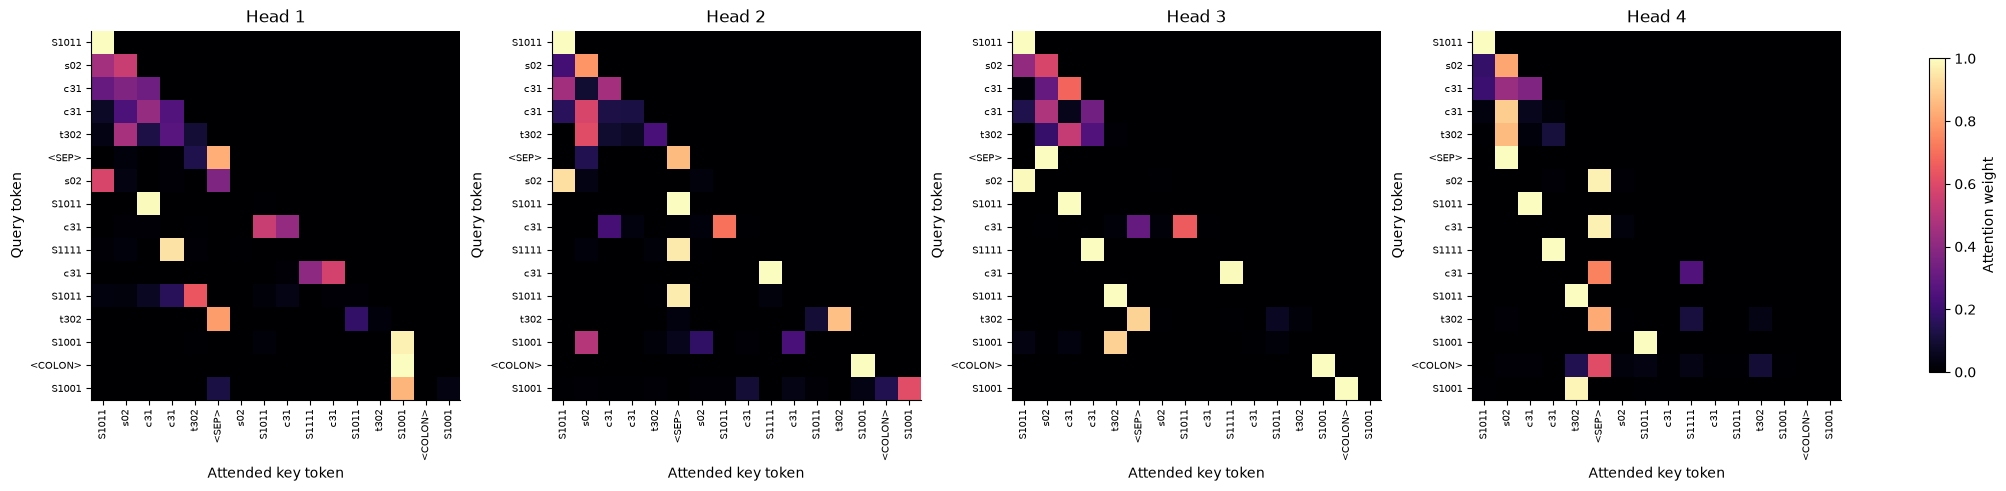

In [33]:
@torch.no_grad()
def plot_generated_attention(model, circuit, tokenizer, device):
    """Show attention on a model-generated sequence, not a gold-forced trace."""
    prompt = torch.tensor([tokenizer.prompt(circuit)], device=device)
    generated = generate(model, prompt, 2 * len(circuit.gates) + 3, tokenizer.eos)
    prefix = generated[:, :-1]  # Positions that predicted the continuation.
    _, attention = model(prefix, return_attention=True)
    labels = tokenizer.decode(prefix[0]).split()
    weights = attention[0].cpu().numpy()
    fig, axes = plt.subplots(1, len(weights), figsize=(20, 5), constrained_layout=True)
    for head, ax in enumerate(np.atleast_1d(axes)):
        image = ax.imshow(weights[head], vmin=0, vmax=1, cmap="magma")
        ax.set(title=f"Head {head + 1}", xlabel="Attended key token", ylabel="Query token")
        ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=7)
        ax.set_yticks(range(len(labels)), labels, fontsize=7)
    fig.colorbar(image, ax=np.atleast_1d(axes).tolist(), shrink=0.7, label="Attention weight")
    plt.show()


plot_generated_attention(models["process"], test_circuits[0], tokenizer, DEVICE)

Attention rows show where each position reads earlier tokens. Above-diagonal
entries must be zero because of causality. These plots can suggest routing
patterns; attention alone does not prove which computation caused an answer.

## 12. What this run establishes

The reference is checked on every first-step state/gate pair, teacher-forced steps,
and free-running test traces. These are finite checks of the construction.
The learned models are assessed separately on local probes and generated outputs.
The table below reports actual results; no accuracy target is assumed.

The two learned models share an architecture. The hand-coded model is a larger
constructive reference, not a capacity-equivalent initialization. This experiment
changes supervision format, target-token count, and sequence length together.
The process-prefix probes also differ from the outcome model's training format.
Consequently, a gap is not by itself a theorem about identifiability, optimizer
failure, or arbitrary-depth reasoning.

**Try next:** change `STEPS` or `MODEL_SEED` and rerun; compare teacher-forced accuracy
with exact free generation; inspect a gate subset in the animation. Testing new
depths or probe contexts requires a separately defined evaluation, not merely
changing the training distribution and calling it generalization.

In [34]:
final = pd.DataFrame([
    {"model": "Hand-coded process Transformer", **fixed_evaluation},
    *[{"model": f"{mode}-trained Transformer",
       **evaluate(model, mode, operator_probe, teacher_probes, generation_eval, tokenizer)}
      for mode, model in models.items()],
])
display(final)

,model,local_accuracy,oracle_probability,frobenius_distance,state_token_mass,teacher_step_accuracy,exact_continuation,final_answer,trace_state_accuracy
0,Hand-coded process Transformer,1.000000,1.000000,2.283933e-13,1.000000,1.0000,1.00,1.00,1.0
1,outcome-trained Transformer,0.069712,0.057964,2.068483e+01,0.900757,0.0375,0.24,0.24,NaN
2,process-trained Transformer,1.000000,0.999995,4.776429e-09,1.000000,1.0000,1.00,1.00,1.0
